# 06 - Trade-off de Custo (FP vs FN) com Reuso de Modelos

## Objetivo deste notebook
Executar a análise de trade-off de custo **sem duplicar treinamentos**: aqui reutilizamos modelos já treinados e registrados no MLflow nos notebooks anteriores.

Este notebook foi desenhado para:
- carregar um modelo existente (MLP ou sklearn) via `model_uri` do MLflow;
- gerar probabilidades no conjunto de teste;
- varrer thresholds e calcular impacto de FP/FN em valor financeiro;
- recomendar o threshold orientado a negócio.

## Conexão com os notebooks anteriores
- `04_mlp_training_early_stopping.ipynb`: treinamento e logging do MLP no MLflow.
- `05_compare_mlp_baselines.ipynb`: comparação técnica entre famílias de modelos.
- **Este notebook 06**: decisão operacional de threshold com base em custo/valor.

## Premissas e observações
- Dataset: `data/Telco_customer_churn_ready.csv` (saída do EDA).
- Target: `Churn Value` (0 = não churn, 1 = churn).
- Variável de negócio: `CLTV` (valor do cliente).
- Estratégia deste notebook: **não treinar novamente**; apenas carregar modelo já existente no MLflow.

### Premissas de custo (hipóteses ajustáveis)
- `CUSTO_ACAO_RETENCAO`: custo para acionar retenção em cliente sinalizado.
- `TAXA_SUCESSO_RETENCAO`: taxa esperada de sucesso da ação quando o cliente realmente churnaria.

Valor esperado por tipo de decisão:
- **TP**: `TAXA_SUCESSO_RETENCAO * CLTV - CUSTO_ACAO_RETENCAO`
- **FP**: `-CUSTO_ACAO_RETENCAO`
- **FN**: `-CLTV`
- **TN**: `0`

### Saída esperada
- threshold ótimo por F1 (visão técnica);
- threshold ótimo por valor financeiro (visão de negócio);
- recomendação operacional baseada em retorno estimado.

In [19]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import mlflow.pytorch
import torch

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Reprodutibilidade.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Resolve tracking uri de forma robusta para diferentes diretorios de execucao.
MLFLOW_DB_CANDIDATES = [
    Path('mlflow.db'),
    Path('../mlflow.db'),
]
MLFLOW_DB_PATH = next((p for p in MLFLOW_DB_CANDIDATES if p.exists()), Path('mlflow.db'))
mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB_PATH.resolve().as_posix()}")

READY_PATH_CANDIDATES = [
    Path('../data/Telco_customer_churn_ready.csv'),
    Path('data/Telco_customer_churn_ready.csv'),
]

DATA_PATH = next((p for p in READY_PATH_CANDIDATES if p.exists()), None)
assert DATA_PATH is not None, (
    'Arquivo tratado nao encontrado. Execute o notebook de EDA para gerar Telco_customer_churn_ready.csv.'
)

print(f'Dataset encontrado em: {DATA_PATH.resolve()}')
print(f'Tracking URI MLflow: {mlflow.get_tracking_uri()}')
print(f'Dispositivo PyTorch: {DEVICE}')

Dataset encontrado em: C:\Users\azvef\Projeto FIAP 1\9mlet-tech-challenge-1-churn-prevision\data\Telco_customer_churn_ready.csv
Tracking URI MLflow: sqlite:///C:/Users/azvef/Projeto FIAP 1/9mlet-tech-challenge-1-churn-prevision/notebooks/mlflow.db
Dispositivo PyTorch: cpu


In [11]:
# Carrega dados e prepara o mesmo esquema de split do notebook 05 (64/16/20).
df = pd.read_csv(DATA_PATH)

TARGET = 'Churn Value'
assert TARGET in df.columns, 'Coluna alvo não encontrada.'
assert 'CLTV' in df.columns, 'Coluna CLTV não encontrada no dataset pronto.'

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=SEED, stratify=y_trainval
)

# Mantemos versão escalada para modelos que precisam de normalização.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print('Shape geral:', df.shape)
print('Treino:', X_train.shape, '| churn=', round(y_train.mean(), 4))
print('Val   :', X_val.shape, '| churn=', round(y_val.mean(), 4))
print('Teste :', X_test.shape, '| churn=', round(y_test.mean(), 4))

Shape geral: (7043, 1163)
Treino: (4507, 1162) | churn= 0.2654
Val   : (1127, 1162) | churn= 0.2653
Teste : (1409, 1162) | churn= 0.2654


In [21]:
# Configuração do modelo a ser analisado (sem re-treino).
# Opções de framework: 'pytorch' ou 'sklearn'.
MODEL_FRAMEWORK = 'pytorch'

# Para MLP do notebook 04 (padrão):
DEFAULT_EXPERIMENT = 'MLP-Churn-EarlyStoppingBatching'
DEFAULT_RUN_NAME = '04_mlp_training_early_stopping'

# Caso queira fixar manualmente um run/modelo, preencha MODEL_URI.
# Exemplo: runs:/<run_id>/model
MODEL_URI = None

# Define se o modelo espera dados escalados (True) ou dados brutos (False).
USE_SCALED_INPUT = True

if MODEL_URI is None:
    runs = mlflow.search_runs(
        experiment_names=[DEFAULT_EXPERIMENT],
        filter_string=f"tags.mlflow.runName = '{DEFAULT_RUN_NAME}'",
        order_by=['start_time DESC'],
        max_results=1,
    )
    assert not runs.empty, (
        f'Run não encontrada para experimento={DEFAULT_EXPERIMENT} e run_name={DEFAULT_RUN_NAME}.'
    )
    run_id = runs.iloc[0]['run_id']
    MODEL_URI = f'runs:/{run_id}/model'
else:
    run_id = MODEL_URI.split('/')[1] if MODEL_URI.startswith('runs:/') else 'manual_uri'

print(f'MODEL_FRAMEWORK: {MODEL_FRAMEWORK}')
print(f'MODEL_URI      : {MODEL_URI}')

# Geração de probabilidade do modelo carregado.
if MODEL_FRAMEWORK == 'pytorch':
    model = mlflow.pytorch.load_model(MODEL_URI).to(DEVICE)
    model.eval()
    X_eval = torch.tensor(X_test_s if USE_SCALED_INPUT else X_test.values, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        y_proba = torch.sigmoid(model(X_eval)).squeeze(1).cpu().numpy()
elif MODEL_FRAMEWORK == 'sklearn':
    model = mlflow.sklearn.load_model(MODEL_URI)
    X_eval = X_test_s if USE_SCALED_INPUT else X_test.values
    y_proba = model.predict_proba(X_eval)[:, 1]
else:
    raise ValueError("MODEL_FRAMEWORK deve ser 'pytorch' ou 'sklearn'.")

# Métricas de ranking (não dependem de threshold fixo).
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

print(f'ROC-AUC: {roc_auc:.4f}')
print(f'PR-AUC : {pr_auc:.4f}')

MODEL_FRAMEWORK: pytorch
MODEL_URI      : runs:/8c0039f74f7a46a5a3f5fc089a779d76/model
ROC-AUC: 0.7668
PR-AUC : 0.5212


## Simulação de custo por threshold
Nesta etapa, usando as probabilidades do modelo já treinado, fazemos:
- varredura de thresholds;
- cálculo de precision, recall, F1;
- cálculo de valor financeiro por combinação de FP/FN/TP/TN.

Assim, a escolha do threshold é feita por **valor de negócio** e não apenas por métrica técnica.

In [20]:
# Premissas de negócio (ajustáveis).
CUSTO_ACAO_RETENCAO = 80.0
TAXA_SUCESSO_RETENCAO = 0.35

thresholds = np.linspace(0.05, 0.95, 19)
records = []

cltv_test = X_test['CLTV'].values
y_true = y_test.values

for thr in thresholds:
    y_pred = (y_proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    is_tp = (y_true == 1) & (y_pred == 1)
    is_fp = (y_true == 0) & (y_pred == 1)
    is_fn = (y_true == 1) & (y_pred == 0)

    ganho_tp = (TAXA_SUCESSO_RETENCAO * cltv_test[is_tp] - CUSTO_ACAO_RETENCAO).sum()
    custo_fp = -CUSTO_ACAO_RETENCAO * is_fp.sum()
    custo_fn = -cltv_test[is_fn].sum()
    valor_total = ganho_tp + custo_fp + custo_fn

    records.append({
        'threshold': thr,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'valor_total': valor_total,
    })

tradeoff_df = pd.DataFrame(records)
best_f1_row = tradeoff_df.loc[tradeoff_df['f1'].idxmax()]
best_value_row = tradeoff_df.loc[tradeoff_df['valor_total'].idxmax()]

display(tradeoff_df.sort_values('valor_total', ascending=False).head())

print('Melhor limiar por F1      :', round(float(best_f1_row['threshold']), 2))
print('Melhor limiar por valor   :', round(float(best_value_row['threshold']), 2))
print('Valor total máximo (R$)   :', round(float(best_value_row['valor_total']), 2))

,threshold,tn,fp,fn,tp,precision,recall,f1,valor_total
0,0.05,156,879,4,370,0.296237,0.989305,0.455946,412024.85
1,0.10,339,696,21,353,0.336511,0.943850,0.496135,322346.85
2,0.15,455,580,42,332,0.364035,0.887701,0.516330,216009.40
3,0.20,569,466,55,319,0.406369,0.852941,0.550475,146211.60
4,0.25,657,378,83,291,0.434978,0.778075,0.558006,-16559.15


Melhor limiar por F1      : 0.25
Melhor limiar por valor   : 0.05
Valor total máximo (R$)   : 412024.85


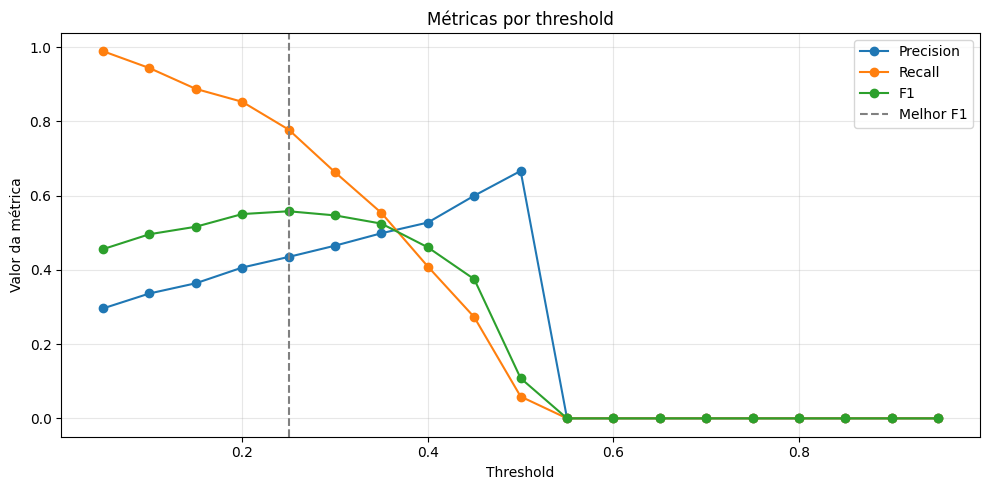

In [14]:
# Visual 1: métricas por threshold.
plt.figure(figsize=(10, 5))
plt.plot(tradeoff_df['threshold'], tradeoff_df['precision'], marker='o', label='Precision')
plt.plot(tradeoff_df['threshold'], tradeoff_df['recall'], marker='o', label='Recall')
plt.plot(tradeoff_df['threshold'], tradeoff_df['f1'], marker='o', label='F1')
plt.axvline(best_f1_row['threshold'], linestyle='--', color='gray', label='Melhor F1')
plt.title('Métricas por threshold')
plt.xlabel('Threshold')
plt.ylabel('Valor da métrica')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Como ler o gráfico de métricas por limiar
- Eixo X: limiar (`threshold`) usado para transformar probabilidade em classe 0/1.
- Eixo Y: valor da métrica (de 0 a 1).
- Curva **Precision**: entre os clientes previstos como churn, quantos realmente são churn.
- Curva **Recall**: entre os churns reais, quantos o modelo conseguiu capturar.
- Curva **F1**: equilíbrio entre precision e recall.

**Interpretação prática**:
- Se o limiar cai, geralmente recall sobe (captura mais churn), mas precision tende a cair (mais alarmes falsos).
- Se o limiar sobe, geralmente precision sobe, mas recall tende a cair (perde churn real).
- A linha vertical marca o melhor limiar por F1 (visão técnica).

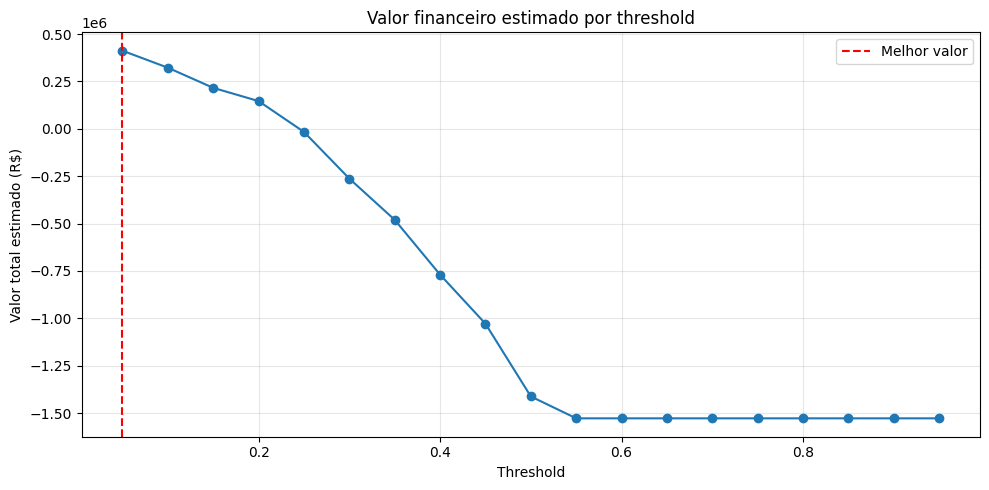

In [15]:
# Visual 2: valor financeiro por threshold.
plt.figure(figsize=(10, 5))
plt.plot(tradeoff_df['threshold'], tradeoff_df['valor_total'], marker='o')
plt.axvline(best_value_row['threshold'], linestyle='--', color='red', label='Melhor valor')
plt.title('Valor financeiro estimado por threshold')
plt.xlabel('Threshold')
plt.ylabel('Valor total estimado (R$)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Como ler o gráfico de valor financeiro
- Eixo X: limiar testado.
- Eixo Y: valor total estimado com suas premissas de custo.
- Linha vertical vermelha: limiar que maximiza o valor total.

**Interpretação prática**:
- O melhor limiar financeiro pode ser diferente do melhor F1.
- Isso acontece porque o negócio "pesa" erros de forma desigual (FN pode custar muito mais que FP, por exemplo).
- O ponto mais alto da curva é o melhor ponto para decisão operacional, dado o cenário atual de custos.

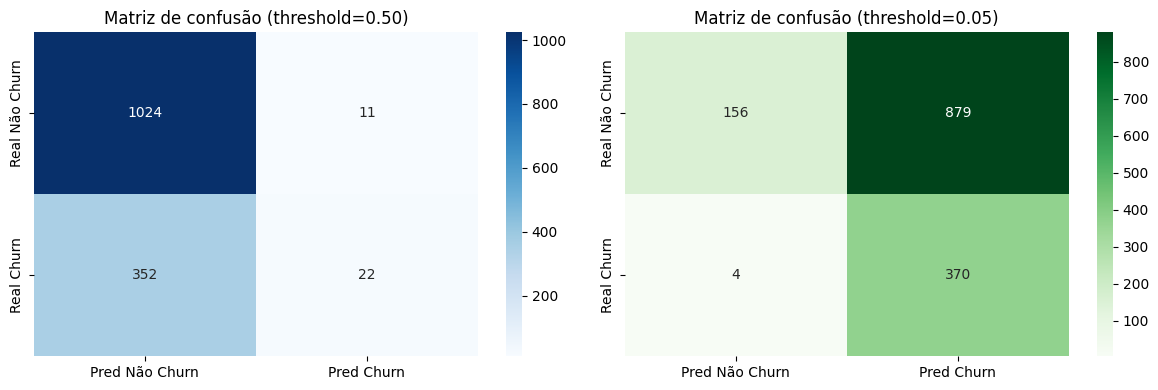

Leitura da matriz de confusão:
- TN: não churn corretamente classificado.
- FP: falso alarme (aciona custo de retenção sem necessidade).
- FN: churn perdido (perda de valor do cliente).
- TP: churn identificado para ação de retenção.


In [16]:
def confusion_df(y_true_arr, y_proba_arr, thr):
    y_pred_arr = (y_proba_arr >= thr).astype(int)
    cm = confusion_matrix(y_true_arr, y_pred_arr, labels=[0, 1])
    return pd.DataFrame(
        cm,
        index=['Real Não Churn', 'Real Churn'],
        columns=['Pred Não Churn', 'Pred Churn'],
    )

cm_050 = confusion_df(y_true, y_proba, 0.50)
cm_best = confusion_df(y_true, y_proba, float(best_value_row['threshold']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm_050, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de confusão (threshold=0.50)')

sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f"Matriz de confusão (threshold={float(best_value_row['threshold']):.2f})")

plt.tight_layout()
plt.show()

print('Leitura da matriz de confusão:')
print('- TN: não churn corretamente classificado.')
print('- FP: falso alarme (aciona custo de retenção sem necessidade).')
print('- FN: churn perdido (perda de valor do cliente).')
print('- TP: churn identificado para ação de retenção.')

## Conclusão da análise

### Leitura técnica
- ROC-AUC e PR-AUC mostram a capacidade de separação do modelo escolhido.
- F1 sugere um threshold de equilíbrio entre precision e recall.

### Leitura de negócio
- O threshold ótimo por valor pode ser diferente do melhor F1.
- A decisão operacional deve priorizar o ponto de maior retorno financeiro estimado.

### Recomendação
Usar o threshold `best_value_row['threshold']` como ponto inicial de operação e recalibrar periodicamente conforme custo de campanha e taxa real de sucesso de retenção.

In [18]:
# Registro desta análise de trade-off no MLflow (sem novo treinamento).
mlflow.set_experiment('Churn-Tradeoff-Custo-FP-FN')

with mlflow.start_run(run_name='06_tradeoff_reuso_modelo') as run:
    mlflow.log_param('seed', SEED)
    mlflow.log_param('dataset', DATA_PATH.name)
    mlflow.log_param('model_framework', MODEL_FRAMEWORK)
    mlflow.log_param('model_uri', MODEL_URI)
    mlflow.log_param('use_scaled_input', USE_SCALED_INPUT)
    mlflow.log_param('custo_acao_retencao', CUSTO_ACAO_RETENCAO)
    mlflow.log_param('taxa_sucesso_retencao', TAXA_SUCESSO_RETENCAO)

    mlflow.log_metric('roc_auc', float(roc_auc))
    mlflow.log_metric('pr_auc', float(pr_auc))
    mlflow.log_metric('best_f1_threshold', float(best_f1_row['threshold']))
    mlflow.log_metric('best_value_threshold', float(best_value_row['threshold']))
    mlflow.log_metric('best_value_total', float(best_value_row['valor_total']))

print('Analise registrada no MLflow.')
print(f'Run ID: {run.info.run_id}')

Analise registrada no MLflow.
Run ID: e01eb332eb544975a6368ce682c8162e
